## Part II – Vision Task: Image Classification with Convolutional Neural Networks
### Dataset: Vegetable Image Dataset (15 Classes)
---

## Install & Import Libraries

In [52]:
!pip install matplotlib seaborn numpy pillow squarify scikit-learn -q

In [53]:
import os, random, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import squarify
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Load Dataset from Kaggle


In [54]:
import os

# Auto-detect dataset path
print('=== Exploring /kaggle/input ===')
for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

BASE_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'train' in dirs and 'test' in dirs and 'validation' in dirs:
        BASE_DIR = root
        break

if BASE_DIR:
    print(f'\n Dataset found at: {BASE_DIR}')
else:
    print('\n Dataset not found! Please add dataset via Add Data panel')


=== Exploring /kaggle/input ===
/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/misrakahmed
/kaggle/input/datasets/misrakahmed/vegetable-image-dataset
/kaggle/input/datasets/misrakahmed/vegetable-image-dataset/Vegetable Images
/kaggle/input/datasets/misrakahmed/vegetable-image-dataset/Vegetable Images/validation
/kaggle/input/datasets/misrakahmed/vegetable-image-dataset/Vegetable Images/validation/Broccoli
/kaggle/input/datasets/misrakahmed/vegetable-image-dataset/Vegetable Images/validation/Capsicum
/kaggle/input/datasets/misrakahmed/vegetable-image-dataset/Vegetable Images/validation/Bottle_Gourd
/kaggle/input/datasets/misrakahmed/vegetable-image-dataset/Vegetable Images/validation/Radish
/kaggle/input/datasets/misrakahmed/vegetable-image-dataset/Vegetable Images/validation/Tomato
/kaggle/input/datasets/misrakahmed/vegetable-image-dataset/Vegetable Images/validation/Brinjal
/kaggle/input/datasets/misrakahmed/vegetable-image-dataset/Vegetable Images/validation/Pumpkin
/kag

In [55]:
# Dataset already extracted on Kaggle
print('Dataset path:', BASE_DIR)
print('Splits found:', os.listdir(BASE_DIR))


Dataset path: /kaggle/input/datasets/misrakahmed/vegetable-image-dataset/Vegetable Images
Splits found: ['validation', 'test', 'train']


## Set Paths

In [56]:
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')
VAL_DIR   = os.path.join(BASE_DIR, 'validation')

print('Splits found:', os.listdir(BASE_DIR))
print('Classes:', sorted(os.listdir(TRAIN_DIR)))


Splits found: ['validation', 'test', 'train']
Classes: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']


## Sample 30% of Dataset for Faster Training
To reduce training time, we randomly copy 30% of images from each class/split into a new directory. This keeps class balance intact and avoids modifying the original dataset.

In [ ]:
import shutil, random

SAMPLE_FRACTION = 0.30
SAMPLE_BASE     = '/kaggle/working/Vegetable_Images_30pct'  
random.seed(42)

def sample_split(src_split_dir, dst_split_dir, fraction):
    """Copy fraction of images per class from src to dst."""
    os.makedirs(dst_split_dir, exist_ok=True)
    for cls in sorted(os.listdir(src_split_dir)):
        src_cls = os.path.join(src_split_dir, cls)
        if not os.path.isdir(src_cls):
            continue
        dst_cls = os.path.join(dst_split_dir, cls)
        os.makedirs(dst_cls, exist_ok=True)
        # Clear existing files so re-run always gives fresh 30%
        for f in os.listdir(dst_cls):
            os.remove(os.path.join(dst_cls, f))
        imgs = [f for f in os.listdir(src_cls)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        n_sample = max(1, int(len(imgs) * fraction))
        chosen   = random.sample(imgs, n_sample)
        for img in chosen:
            shutil.copy2(os.path.join(src_cls, img),
                         os.path.join(dst_cls, img))
        print(f'  {cls}: {n_sample}/{len(imgs)} images copied')

print(f'Sampling {int(SAMPLE_FRACTION*100)}% of dataset to /kaggle/working ...')
sample_split(TRAIN_DIR, os.path.join(SAMPLE_BASE, 'train'),      SAMPLE_FRACTION)
sample_split(VAL_DIR,   os.path.join(SAMPLE_BASE, 'validation'), SAMPLE_FRACTION)
sample_split(TEST_DIR,  os.path.join(SAMPLE_BASE, 'test'),       SAMPLE_FRACTION)
print('\nSampling complete!')

# Override dirs to sampled dataset
TRAIN_DIR = os.path.join(SAMPLE_BASE, 'train')
VAL_DIR   = os.path.join(SAMPLE_BASE, 'validation')
TEST_DIR  = os.path.join(SAMPLE_BASE, 'test')

# Confirm counts
for split, d in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    total = sum(len(os.listdir(os.path.join(d, c)))
                for c in os.listdir(d) if os.path.isdir(os.path.join(d, c)))
    print(f'{split}: {total} images')
print(f'\nTRAIN_DIR now → {TRAIN_DIR}')


Sampling 30% of dataset to /kaggle/working ...
  Bean: 300/1000 images copied
  Bitter_Gourd: 300/1000 images copied
  Bottle_Gourd: 300/1000 images copied
  Brinjal: 300/1000 images copied
  Broccoli: 300/1000 images copied
  Cabbage: 300/1000 images copied
  Capsicum: 300/1000 images copied
  Carrot: 300/1000 images copied
  Cauliflower: 300/1000 images copied
  Cucumber: 300/1000 images copied
  Papaya: 300/1000 images copied
  Potato: 300/1000 images copied
  Pumpkin: 300/1000 images copied
  Radish: 300/1000 images copied
  Tomato: 300/1000 images copied
  Bean: 60/200 images copied
  Bitter_Gourd: 60/200 images copied
  Bottle_Gourd: 60/200 images copied
  Brinjal: 60/200 images copied
  Broccoli: 60/200 images copied
  Cabbage: 60/200 images copied
  Capsicum: 60/200 images copied
  Carrot: 60/200 images copied
  Cauliflower: 60/200 images copied
  Cucumber: 60/200 images copied
  Papaya: 60/200 images copied
  Potato: 60/200 images copied
  Pumpkin: 60/200 images copied
  Radis

---
# PART A - Designing and Analysing CNNs from Scratch
---
## 2.5.1 - Data Understanding, Analysis, Visualisation and Cleaning

### A1. Count images per class per split

In [58]:
def count_images(split_dir):
    counts = {}
    for cls in sorted(os.listdir(split_dir)):
        path = os.path.join(split_dir, cls)
        if os.path.isdir(path):
            counts[cls] = len([f for f in os.listdir(path)
                               if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)
val_counts   = count_images(VAL_DIR)
classes      = list(train_counts.keys())
NUM_CLASSES  = len(classes)

print(f"{'Class':<22} {'Train':>7} {'Test':>7} {'Val':>7} {'Total':>8}")
print("-" * 55)
for c in classes:
    tr, te, va = train_counts[c], test_counts.get(c,0), val_counts.get(c,0)
    print(f"{c:<22} {tr:>7} {te:>7} {va:>7} {tr+te+va:>8}")
print("-" * 55)
total_tr = sum(train_counts.values())
total_te = sum(test_counts.values())
total_va = sum(val_counts.values())
print(f"{'TOTAL':<22} {total_tr:>7} {total_te:>7} {total_va:>7} {total_tr+total_te+total_va:>8}")
print(f"\nNumber of classes: {NUM_CLASSES}")

Class                    Train    Test     Val    Total
-------------------------------------------------------
Bean                       300      60      60      420
Bitter_Gourd               300      60      60      420
Bottle_Gourd               300      60      60      420
Brinjal                    300      60      60      420
Broccoli                   300      60      60      420
Cabbage                    300      60      60      420
Capsicum                   300      60      60      420
Carrot                     300      60      60      420
Cauliflower                300      60      60      420
Cucumber                   300      60      60      420
Papaya                     300      60      60      420
Potato                     300      60      60      420
Pumpkin                    300      60      60      420
Radish                     300      60      60      420
Tomato                     300      60      60      420
------------------------------------------------

### A2. Visualisation – Grouped Bar Chart (class distribution per split)

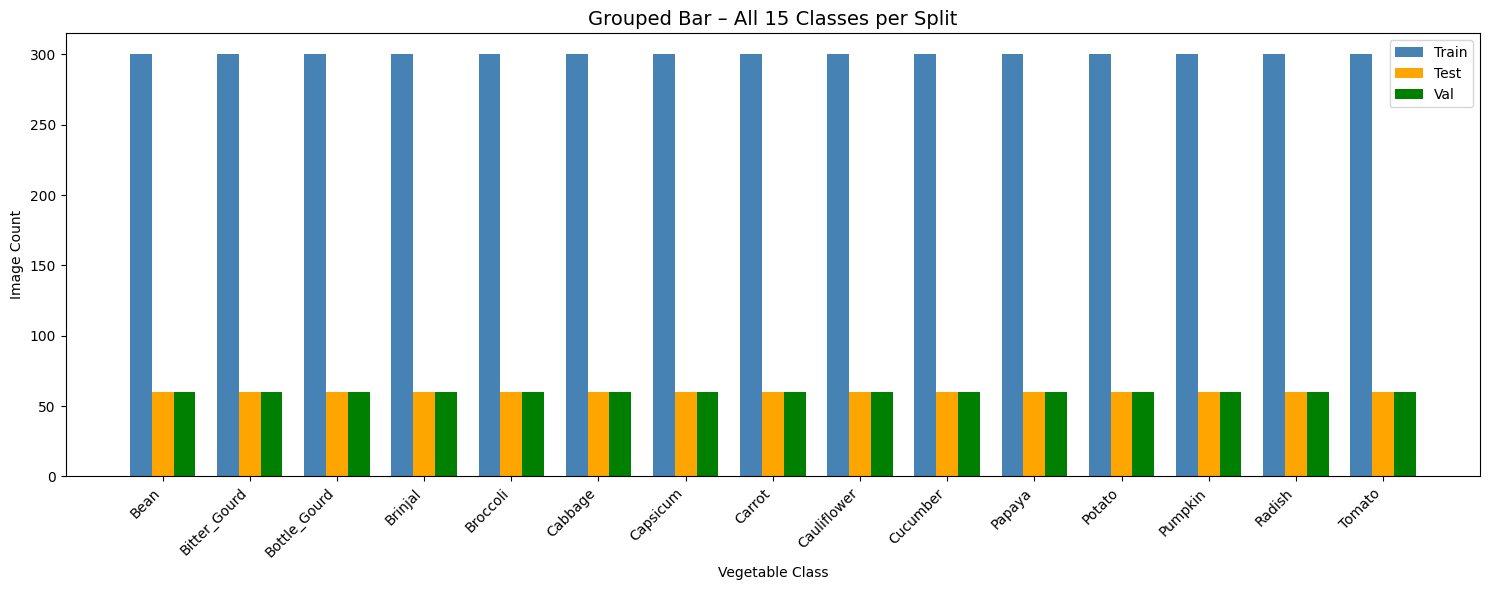

In [59]:
x      = np.arange(len(classes))
width  = 0.25
tr_v   = [train_counts[c] for c in classes]
te_v   = [test_counts.get(c,0) for c in classes]
va_v   = [val_counts.get(c,0) for c in classes]

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - width, tr_v, width, label='Train', color='steelblue')
ax.bar(x,         te_v, width, label='Test',  color='orange')
ax.bar(x + width, va_v, width, label='Val',   color='green')
ax.set_title('Grouped Bar – All 15 Classes per Split', fontsize=14)
ax.set_xlabel('Vegetable Class')
ax.set_ylabel('Image Count')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

### A3. Visualisation – Donut Chart (overall split proportions)

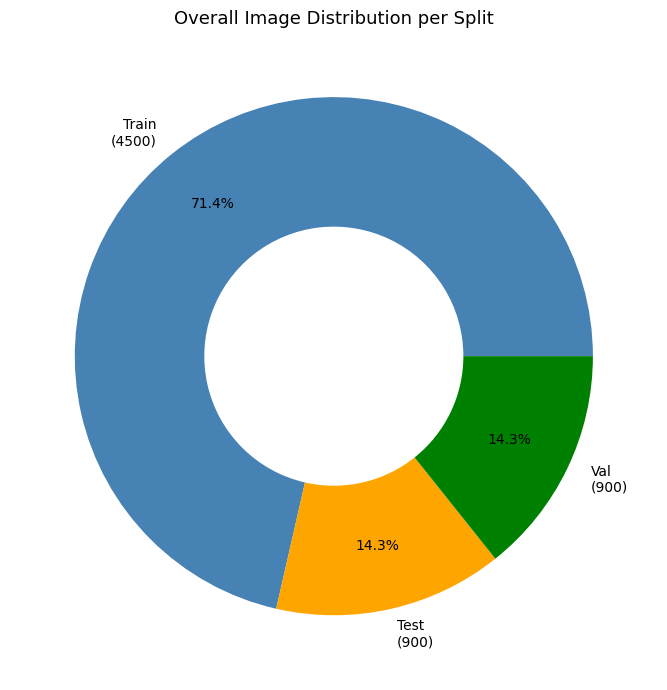

In [60]:
sizes  = [total_tr, total_te, total_va]
labels = [f'Train\n({total_tr})', f'Test\n({total_te})', f'Val\n({total_va})']
colors = ['steelblue', 'orange', 'green']

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
       pctdistance=0.75, wedgeprops=dict(width=0.5))
ax.set_title('Overall Image Distribution per Split', fontsize=13)
plt.tight_layout()
plt.show()

### A4. Visualisation – Treemap (class proportions in training set)

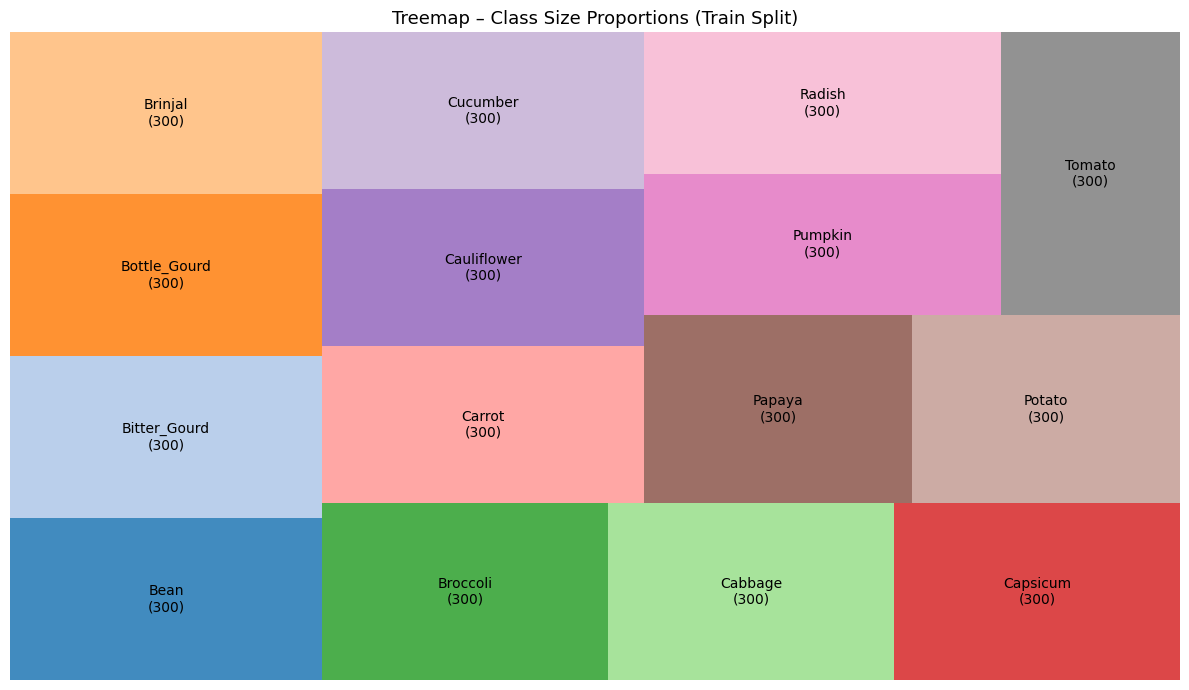

In [61]:
labels_tree = [f"{c}\n({train_counts[c]})" for c in classes]
sizes_tree  = [train_counts[c] for c in classes]
colors_tree = plt.cm.tab20.colors[:len(classes)]

fig, ax = plt.subplots(figsize=(12, 7))
squarify.plot(sizes=sizes_tree, label=labels_tree, color=colors_tree, alpha=0.85, ax=ax)
ax.set_title('Treemap – Class Size Proportions (Train Split)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

### A5. Visualisation – Sample Images per Class

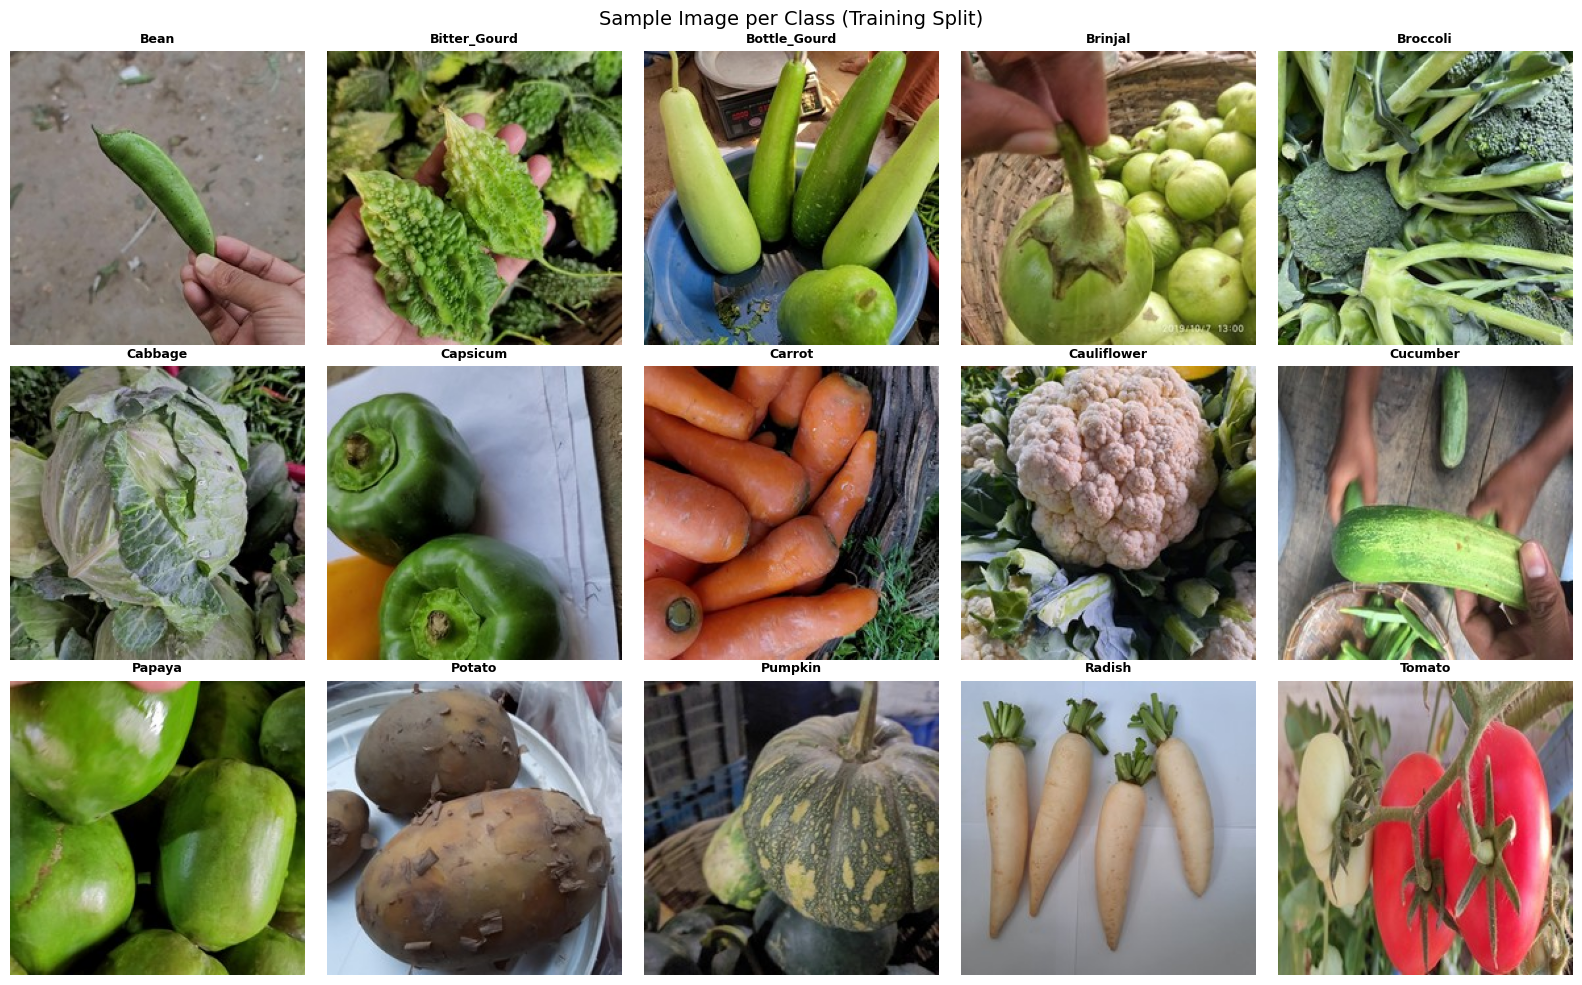

In [62]:
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    img  = Image.open(os.path.join(cls_path, random.choice(imgs)))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9, fontweight='bold')
    axes[i].axis('off')

fig.suptitle('Sample Image per Class (Training Split)', fontsize=14)
plt.tight_layout()
plt.show()

### A6. Preprocessing – Data Generators (Augmentation for training)

In [ ]:
IMG_SIZE   = (128, 128)   
BATCH_SIZE = 32

# Training generator: augmentation + normalisation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.1,
    fill_mode='nearest'
)

# Validation/Test generators: only normalise (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

print("\nClass index mapping:")
print(train_gen.class_indices)

Found 4500 images belonging to 15 classes.
Found 900 images belonging to 15 classes.
Found 900 images belonging to 15 classes.

Class index mapping:
{'Bean': 0, 'Bitter_Gourd': 1, 'Bottle_Gourd': 2, 'Brinjal': 3, 'Broccoli': 4, 'Cabbage': 5, 'Capsicum': 6, 'Carrot': 7, 'Cauliflower': 8, 'Cucumber': 9, 'Papaya': 10, 'Potato': 11, 'Pumpkin': 12, 'Radish': 13, 'Tomato': 14}


### A7. Visualise Augmented Images

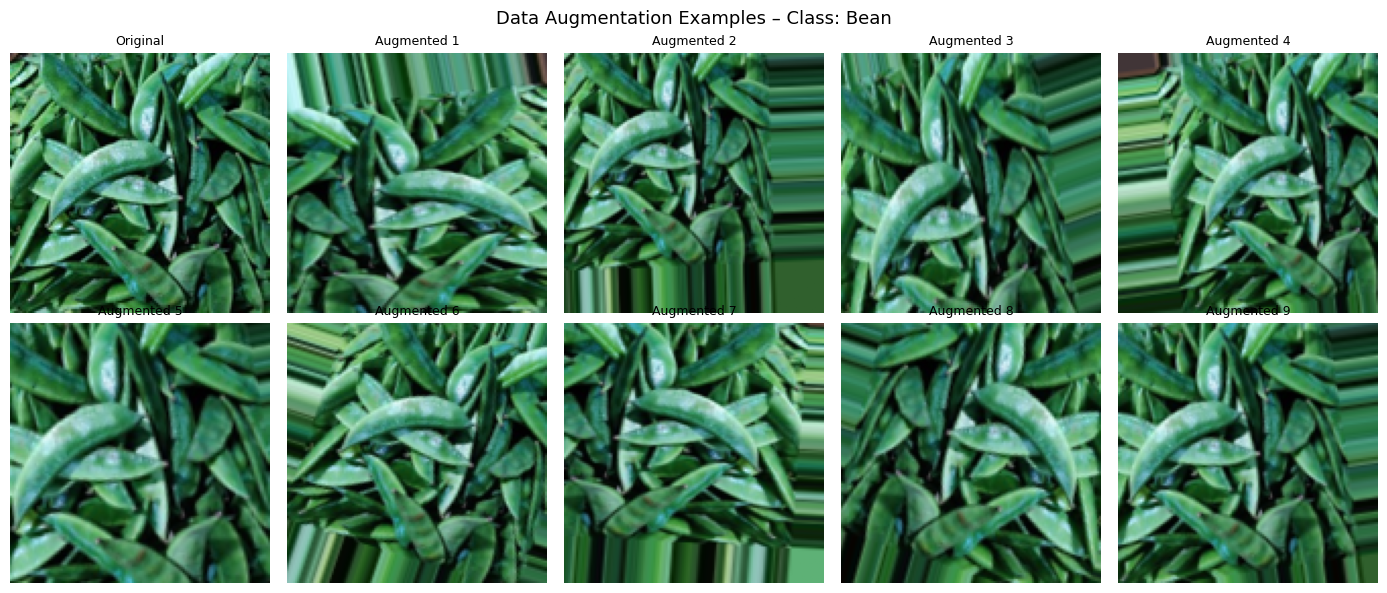

In [64]:
# Show augmented samples for the first class
sample_class = classes[0]
sample_dir   = os.path.join(TRAIN_DIR, sample_class)
sample_img_path = os.path.join(sample_dir,
    [f for f in os.listdir(sample_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))][0])

img_arr  = np.expand_dims(
    np.array(Image.open(sample_img_path).resize(IMG_SIZE)) / 255., axis=0)

aug_gen = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.15, height_shift_range=0.15,
    horizontal_flip=True, zoom_range=0.2, shear_range=0.1, fill_mode='nearest')

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()
axes[0].imshow(img_arr[0])
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')

for i, batch in enumerate(aug_gen.flow(img_arr, batch_size=1)):
    if i >= 9:
        break
    axes[i+1].imshow(batch[0])
    axes[i+1].set_title(f'Augmented {i+1}', fontsize=9)
    axes[i+1].axis('off')

fig.suptitle(f'Data Augmentation Examples – Class: {sample_class}', fontsize=13)
plt.tight_layout()
plt.show()

---
## 2.5.2 – Design, Train and Evaluate a Baseline CNN Model

### B1. Baseline Model Architecture
Architecture: 3 × (Conv2D → MaxPool2D) → Flatten → 3 × Dense → Output (Softmax)

### 2.5.2 - Baseline Model: Architecture Design Rationale


In [ ]:
def build_baseline_model(num_classes, input_shape=(128, 128, 3)):
    model = models.Sequential([
        # Block 1 
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=input_shape, name='conv1'),
        layers.MaxPooling2D((2, 2), name='pool1'),

        # Block 2 
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
        layers.MaxPooling2D((2, 2), name='pool2'),

        # Block 3 
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
        layers.MaxPooling2D((2, 2), name='pool3'),

        # Classifier 
        layers.Flatten(name='flatten'),
        layers.Dense(256, activation='relu', name='fc1'),
        layers.Dense(128, activation='relu', name='fc2'),
        layers.Dense(64,  activation='relu', name='fc3'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline_model(NUM_CLASSES)
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,524,239 (32.52 MB)

 Trainable params: 8,524,239 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

### B2. Train Baseline Model

In [ ]:
EPOCHS = 50
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ]

t0 = time.time()
history_baseline = baseline_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks(),
    verbose=1
)
baseline_train_time = time.time() - t0
print(f"\nBaseline model training time: {baseline_train_time:.1f}s")


Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 158ms/step - accuracy: 0.1964 - loss: 2.3580 - val_accuracy: 0.3622 - val_loss: 1.7958 - learning_rate: 0.0010
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step - accuracy: 0.4501 - loss: 1.5611 - val_accuracy: 0.6144 - val_loss: 1.1126 - learning_rate: 0.0010
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - accuracy: 0.6266 - loss: 1.1283 - val_accuracy: 0.6511 - val_loss: 1.0129 - learning_rate: 0.0010
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 139ms/step - accuracy: 0.6956 - loss: 0.9299 - val_accuracy: 0.7167 - val_loss: 0.8770 - learning_rate: 0.0010
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.7602 - loss: 0.7254 - val_accuracy: 0.8111 - val_loss: 0.6075 - learning_rate: 0.0010
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step - accuracy: 0.7994 - loss: 0.5968 - val_accuracy: 0.7822 - val_loss: 0.6826 - learning_rate: 0.0010
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 139ms/step - accuracy: 0.8

### B3. Plot Training vs Validation – Baseline

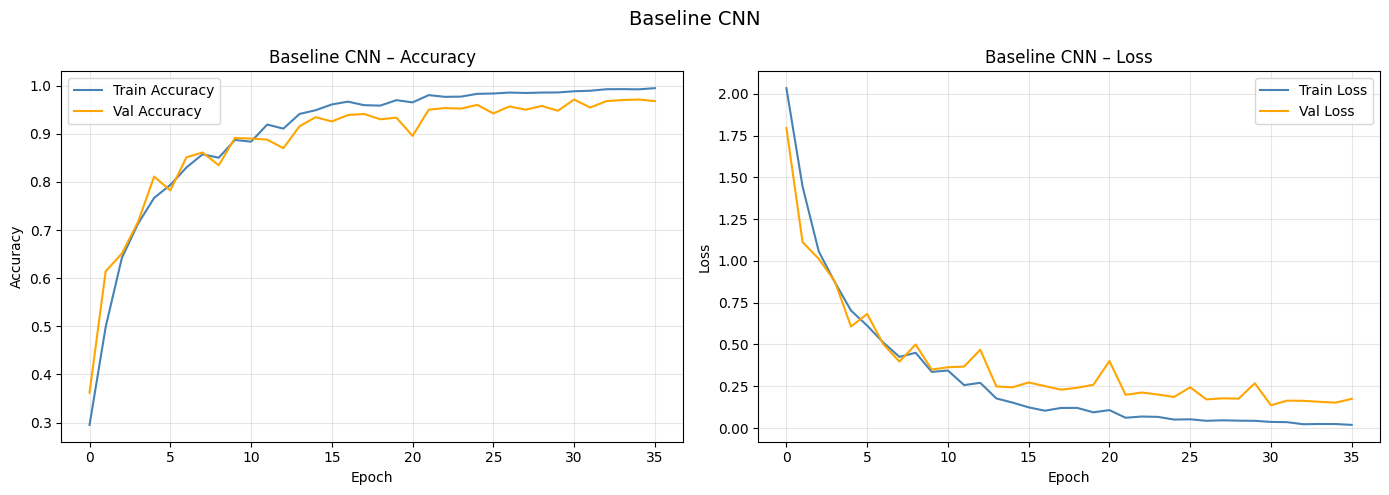

In [67]:
def plot_history(history, title, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
    axes[0].set_title(f'{title} – Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
    axes[1].set_title(f'{title} – Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

plot_history(history_baseline, 'Baseline CNN')

### Baseline CNN - Training Curve Observations


### B4. Evaluate Baseline Model


Baseline CNN – Test Results
  Test Loss    : 0.1125
  Test Accuracy: 97.33%

Classification Report:
              precision    recall  f1-score   support

        Bean      0.967     0.967     0.967        60
Bitter_Gourd      0.983     0.983     0.983        60
Bottle_Gourd      0.968     1.000     0.984        60
     Brinjal      0.983     0.967     0.975        60
    Broccoli      0.935     0.967     0.951        60
     Cabbage      0.919     0.950     0.934        60
    Capsicum      1.000     0.983     0.992        60
      Carrot      1.000     1.000     1.000        60
 Cauliflower      0.950     0.950     0.950        60
    Cucumber      0.967     0.967     0.967        60
      Papaya      1.000     1.000     1.000        60
      Potato      1.000     0.950     0.974        60
     Pumpkin      0.983     0.967     0.975        60
      Radish      0.968     1.000     0.984        60
      Tomato      0.983     0.950     0.966        60

    accuracy                     

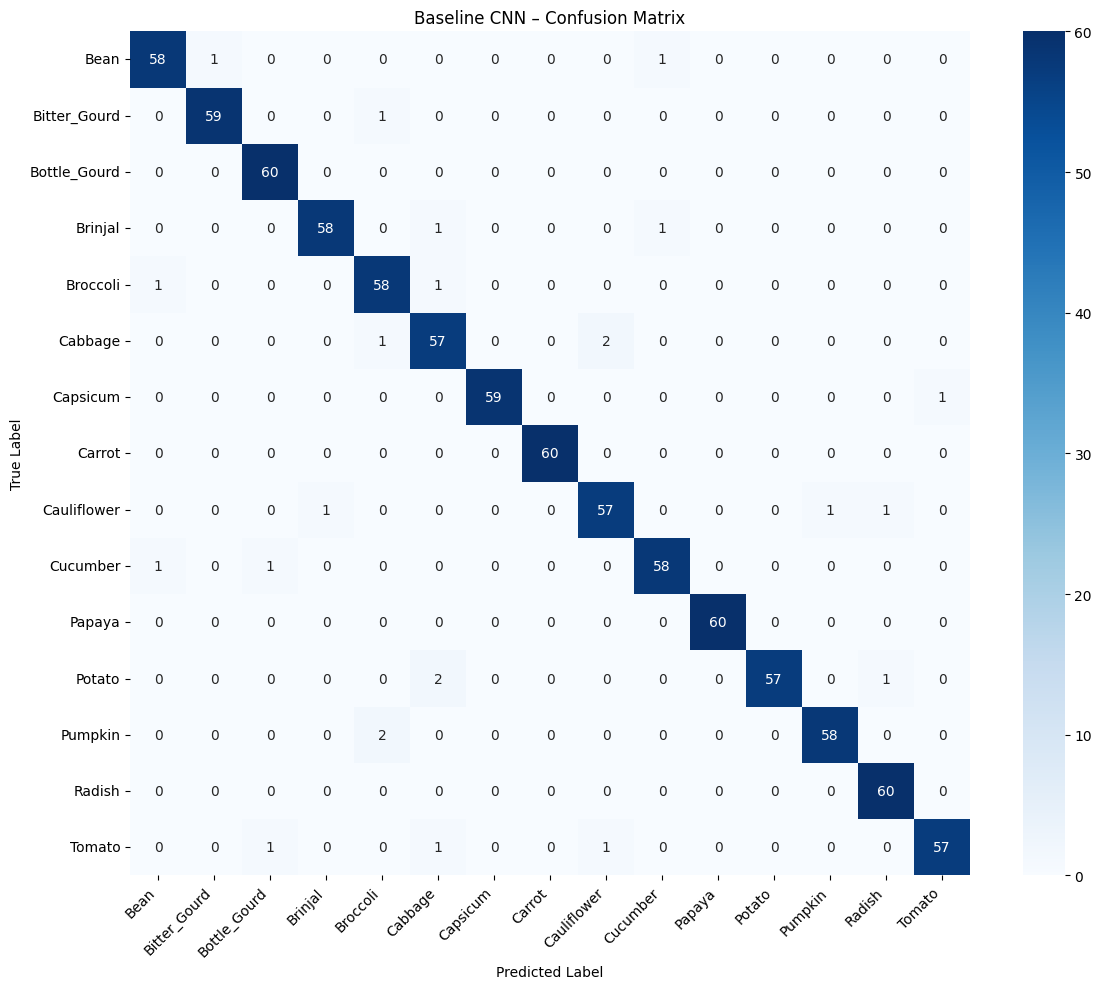

In [68]:
def evaluate_model(model, test_gen, model_name='Model'):
    test_gen.reset()
    loss, acc = model.evaluate(test_gen, verbose=0)
    print(f"\n{'='*50}")
    print(f"{model_name} – Test Results")
    print(f"{'='*50}")
    print(f"  Test Loss    : {loss:.4f}")
    print(f"  Test Accuracy: {acc*100:.2f}%")

    # Predictions
    test_gen.reset()
    y_pred_probs = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes
    class_names = list(test_gen.class_indices.keys())

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
    ax.set_title(f'{model_name} – Confusion Matrix')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return loss, acc, y_pred, y_true

bl_loss, bl_acc, bl_pred, bl_true = evaluate_model(baseline_model, test_gen, 'Baseline CNN')

### Baseline CNN - Evaluation Results and Discussion


### B5. Inference on Sample Images – Baseline

Found 900 images belonging to 15 classes.


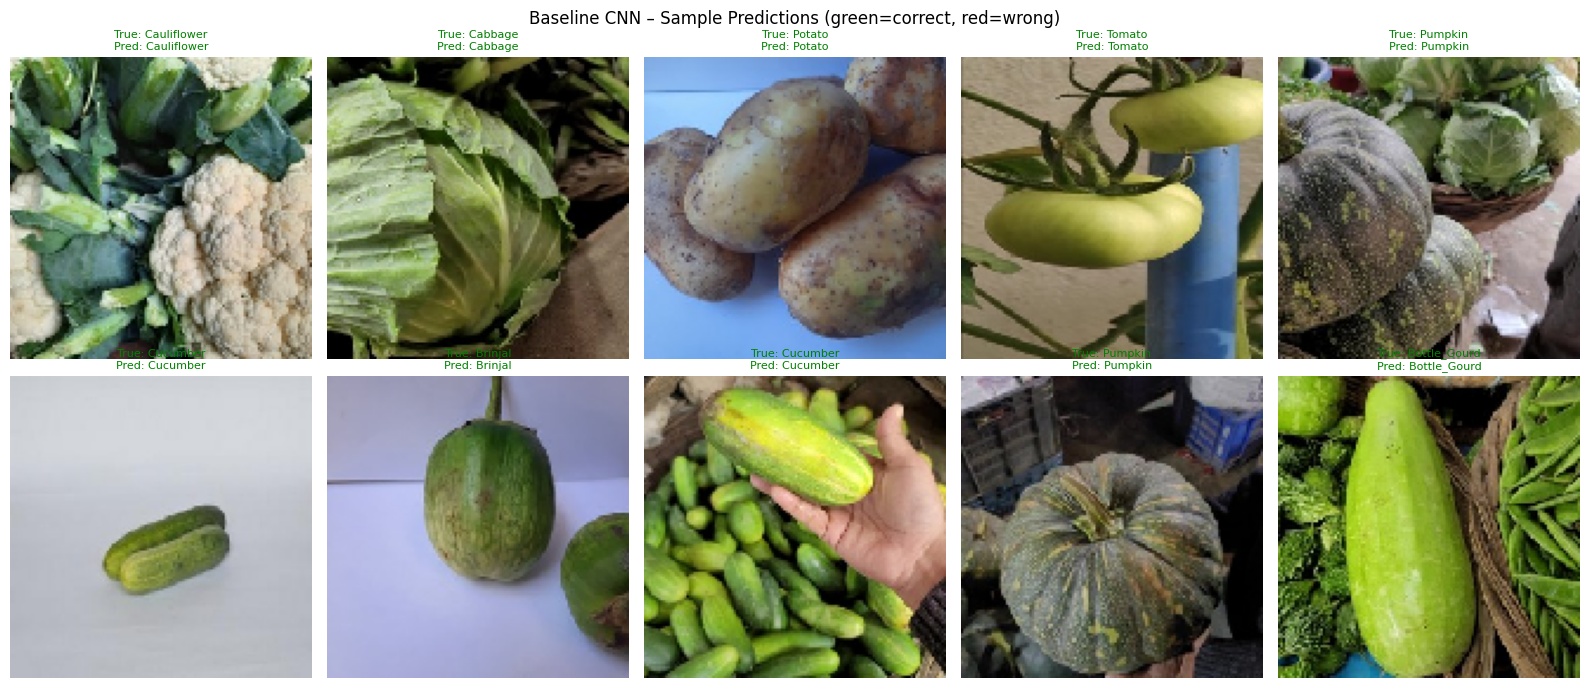

In [69]:
def show_sample_predictions(model, test_dir, class_names, n=10, img_size=(128,128), title='Model'):
    datagen   = ImageDataGenerator(rescale=1./255)
    gen = datagen.flow_from_directory(test_dir, target_size=img_size,
                                       batch_size=n, class_mode='categorical', shuffle=True)
    imgs, labels = next(gen)
    preds = np.argmax(model.predict(imgs, verbose=0), axis=1)
    trues = np.argmax(labels, axis=1)

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    axes = axes.flatten()
    for i in range(n):
        axes[i].imshow(imgs[i])
        color  = 'green' if preds[i] == trues[i] else 'red'
        axes[i].set_title(
            f"True: {class_names[trues[i]]}\nPred: {class_names[preds[i]]}",
            color=color, fontsize=8)
        axes[i].axis('off')
    fig.suptitle(f'{title} – Sample Predictions (green=correct, red=wrong)', fontsize=12)
    plt.tight_layout()
    plt.show()

class_names_list = list(test_gen.class_indices.keys())
show_sample_predictions(baseline_model, TEST_DIR, class_names_list,
                        n=10, title='Baseline CNN')

---
## 2.5.3 – Deeper Architecture with Regularisation Layers

### C1. Deeper Model Architecture
Architecture: 6 × (Conv2D → BatchNorm → MaxPool2D) with Dropout regularisation → 3 × Dense → Output

### 2.5.3 - Deeper Architecture: Design Rationale

In [ ]:
def build_deeper_model(num_classes, input_shape=(128, 128, 3)):
    model = models.Sequential([
        # Block 1 
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),

        # Classifier 
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='Deeper_CNN')
    return model

deeper_model = build_deeper_model(NUM_CLASSES)
deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,142,319 (34.88 MB)

 Trainable params: 9,139,887 (34.87 MB)

 Non-trainable params: 2,432 (9.50 KB)

### C2. Train Deeper Model

In [71]:
t0 = time.time()
history_deeper = deeper_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks(),
    verbose=1
)
deeper_train_time = time.time() - t0
print(f"\nDeeper model training time: {deeper_train_time:.1f}s")
print(f"Baseline training time:     {baseline_train_time:.1f}s")
print(f"Time overhead:              {deeper_train_time - baseline_train_time:.1f}s")


Epoch 1/50


2026-05-09 14:03:59.169651: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:03:59.327028: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:04:00.999495: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:04:01.292964: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 12/141 ━━━━━━━━━━━━━━━━━━━━ 17s 137ms/step - accuracy: 0.1260 - loss: 3.3844

2026-05-09 14:04:14.091970: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:04:14.245294: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:04:15.177123: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:04:15.462518: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


141/141 ━━━━━━━━━━━━━━━━━━━━ 54s 248ms/step - accuracy: 0.2516 - loss: 2.4650 - val_accuracy: 0.0667 - val_loss: 4.1087 - learning_rate: 0.0010
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.4877 - loss: 1.5506 - val_accuracy: 0.1911 - val_loss: 3.6133 - learning_rate: 0.0010
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.5732 - loss: 1.2898 - val_accuracy: 0.2211 - val_loss: 4.3204 - learning_rate: 0.0010
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.6813 - loss: 0.9548 - val_accuracy: 0.7067 - val_loss: 0.8771 - learning_rate: 0.0010
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.7207 - loss: 0.8521 - val_accuracy: 0.7222 - val_loss: 0.9529 - learning_rate: 0.0010
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.7502 - loss: 0.7954 - val_accuracy: 0.6200 - val_loss: 1.3744 - learning_rate: 0.0010
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.7746 - loss:

### C3. Plot Training History – Deeper Model

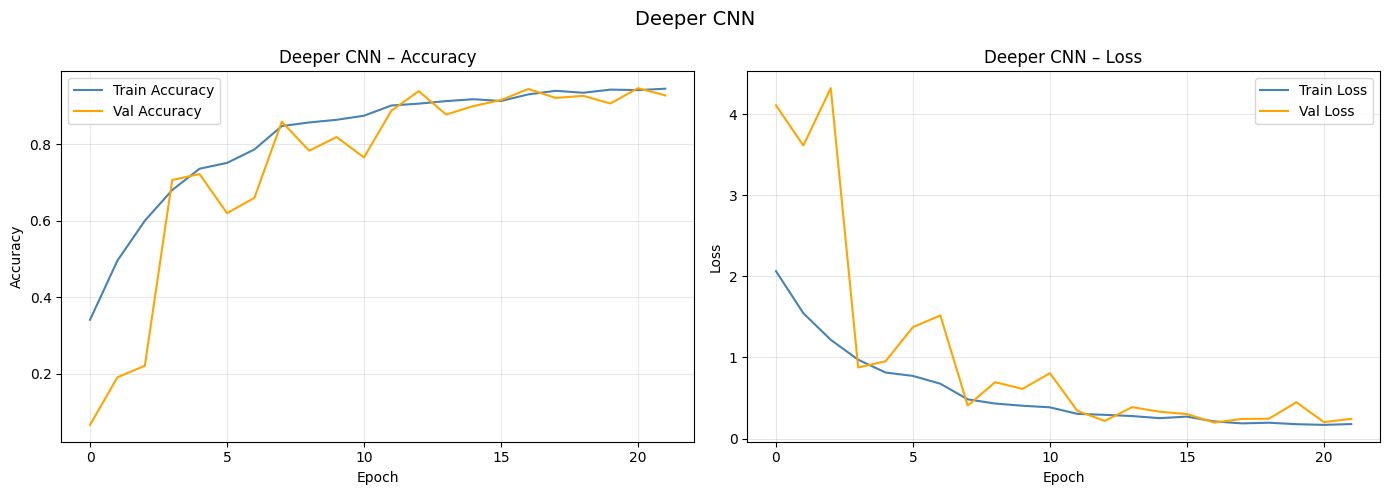

In [72]:
plot_history(history_deeper, 'Deeper CNN',)

### Deeper CNN - Training Curve Observations


### C4. Evaluate Deeper Model


Deeper CNN – Test Results
  Test Loss    : 0.1692
  Test Accuracy: 95.67%

Classification Report:
              precision    recall  f1-score   support

        Bean      0.982     0.933     0.957        60
Bitter_Gourd      0.894     0.983     0.937        60
Bottle_Gourd      0.952     1.000     0.976        60
     Brinjal      0.935     0.967     0.951        60
    Broccoli      0.853     0.967     0.906        60
     Cabbage      0.944     0.850     0.895        60
    Capsicum      1.000     0.933     0.966        60
      Carrot      0.968     1.000     0.984        60
 Cauliflower      0.983     0.967     0.975        60
    Cucumber      0.983     0.983     0.983        60
      Papaya      0.966     0.933     0.949        60
      Potato      1.000     0.983     0.992        60
     Pumpkin      0.952     0.983     0.967        60
      Radish      1.000     1.000     1.000        60
      Tomato      0.963     0.867     0.912        60

    accuracy                       

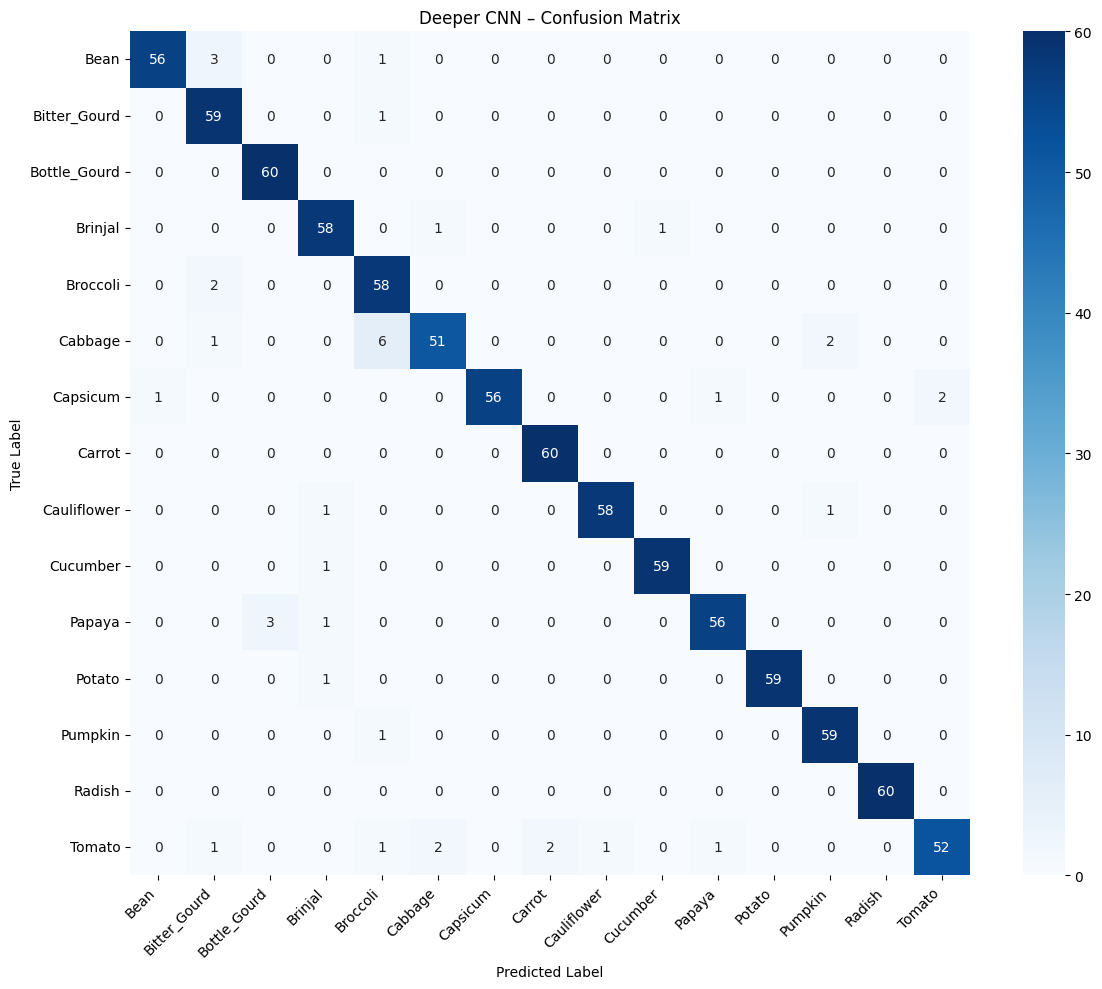

In [73]:
dp_loss, dp_acc, dp_pred, dp_true = evaluate_model(deeper_model, test_gen, 'Deeper CNN')

### Deeper CNN - Evaluation Results and Discussion

### C5. Side-by-Side Loss Curve Comparison

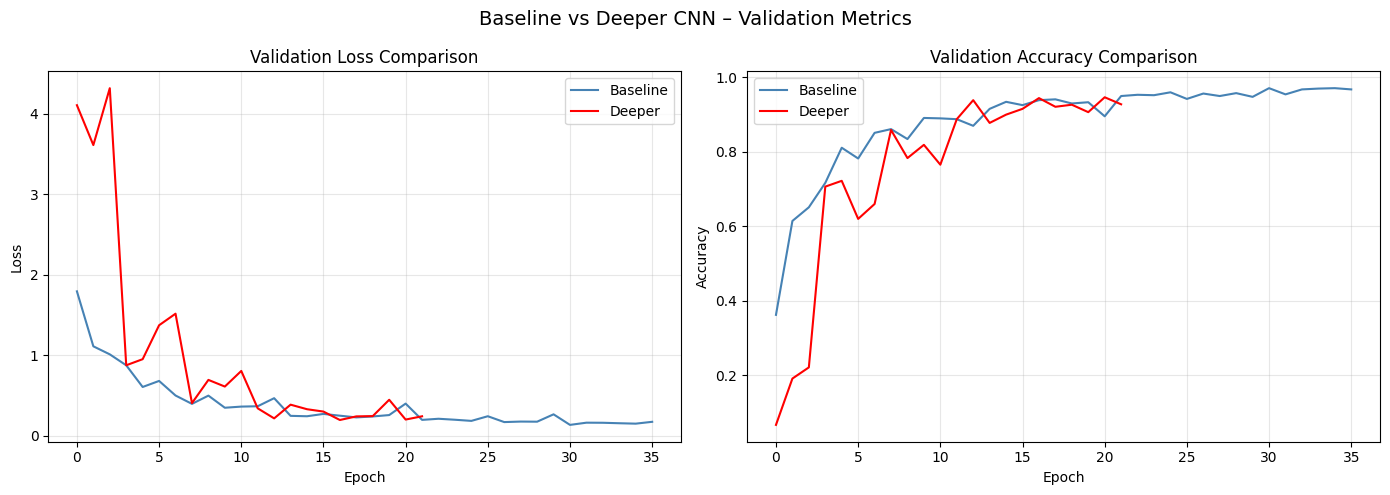

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_baseline.history['val_loss'],    label='Baseline', color='steelblue')
axes[0].plot(history_deeper.history['val_loss'],      label='Deeper',   color='red')
axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_baseline.history['val_accuracy'], label='Baseline', color='steelblue')
axes[1].plot(history_deeper.history['val_accuracy'],   label='Deeper',   color='red')
axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Baseline vs Deeper CNN – Validation Metrics', fontsize=14)
plt.tight_layout()
plt.show()

---
## 2.5.4 - Experimentation and Comparative Analysis

### 2.5.4 - Experimentation and Comparative Analysis: Overview


### D1. Optimizer Experiment – SGD vs Adam on Deeper Architecture

In [ ]:
# SGD Version 
deeper_sgd = build_deeper_model(NUM_CLASSES)
deeper_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Training Deeper CNN with SGD...")
t0 = time.time()
history_sgd = deeper_sgd.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=get_callbacks(), verbose=1
)
sgd_time = time.time() - t0
print(f"SGD training time: {sgd_time:.1f}s")


Training Deeper CNN with SGD...
Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 40s 206ms/step - accuracy: 0.1661 - loss: 2.7968 - val_accuracy: 0.0956 - val_loss: 3.5544 - learning_rate: 0.0100
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.3957 - loss: 1.8278 - val_accuracy: 0.4311 - val_loss: 1.7137 - learning_rate: 0.0100
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.5097 - loss: 1.5099 - val_accuracy: 0.4089 - val_loss: 1.9477 - learning_rate: 0.0100
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.5772 - loss: 1.2733 - val_accuracy: 0.4944 - val_loss: 1.6262 - learning_rate: 0.0100
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.6299 - loss: 1.1430 - val_accuracy: 0.6856 - val_loss: 0.9771 - learning_rate: 0.0100
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.6785 - loss: 0.9837 - val_accuracy: 0.5044 - val_loss: 1.9756 - learning_rate: 0.0100
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━

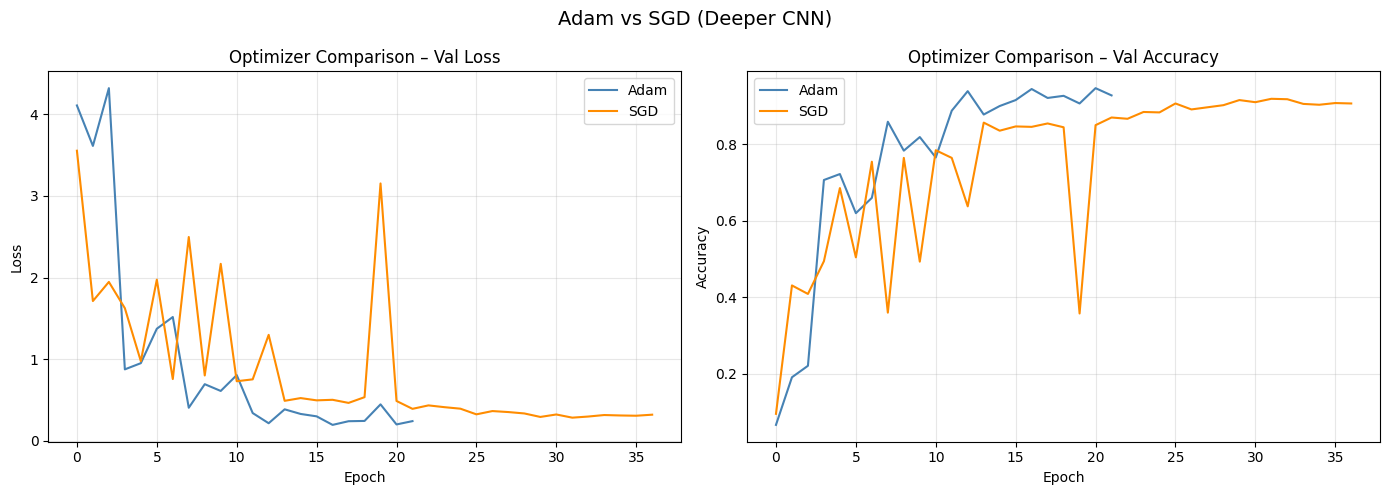

In [ ]:
# Plot SGD vs Adam
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deeper.history['val_loss'], label='Adam', color='steelblue')
axes[0].plot(history_sgd.history['val_loss'],    label='SGD',  color='darkorange')
axes[0].set_title('Optimizer Comparison – Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_deeper.history['val_accuracy'], label='Adam', color='steelblue')
axes[1].plot(history_sgd.history['val_accuracy'],    label='SGD',  color='darkorange')
axes[1].set_title('Optimizer Comparison – Val Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Adam vs SGD (Deeper CNN)', fontsize=14)
plt.tight_layout()
plt.show()


Deeper CNN (SGD) – Test Results
  Test Loss    : 0.2351
  Test Accuracy: 93.11%

Classification Report:
              precision    recall  f1-score   support

        Bean      0.930     0.883     0.906        60
Bitter_Gourd      0.829     0.967     0.892        60
Bottle_Gourd      1.000     1.000     1.000        60
     Brinjal      0.909     0.833     0.870        60
    Broccoli      0.787     0.983     0.874        60
     Cabbage      0.962     0.833     0.893        60
    Capsicum      1.000     0.900     0.947        60
      Carrot      0.984     1.000     0.992        60
 Cauliflower      0.877     0.950     0.912        60
    Cucumber      0.906     0.967     0.935        60
      Papaya      1.000     0.917     0.957        60
      Potato      1.000     0.900     0.947        60
     Pumpkin      0.931     0.900     0.915        60
      Radish      0.983     0.983     0.983        60
      Tomato      0.950     0.950     0.950        60

    accuracy                 

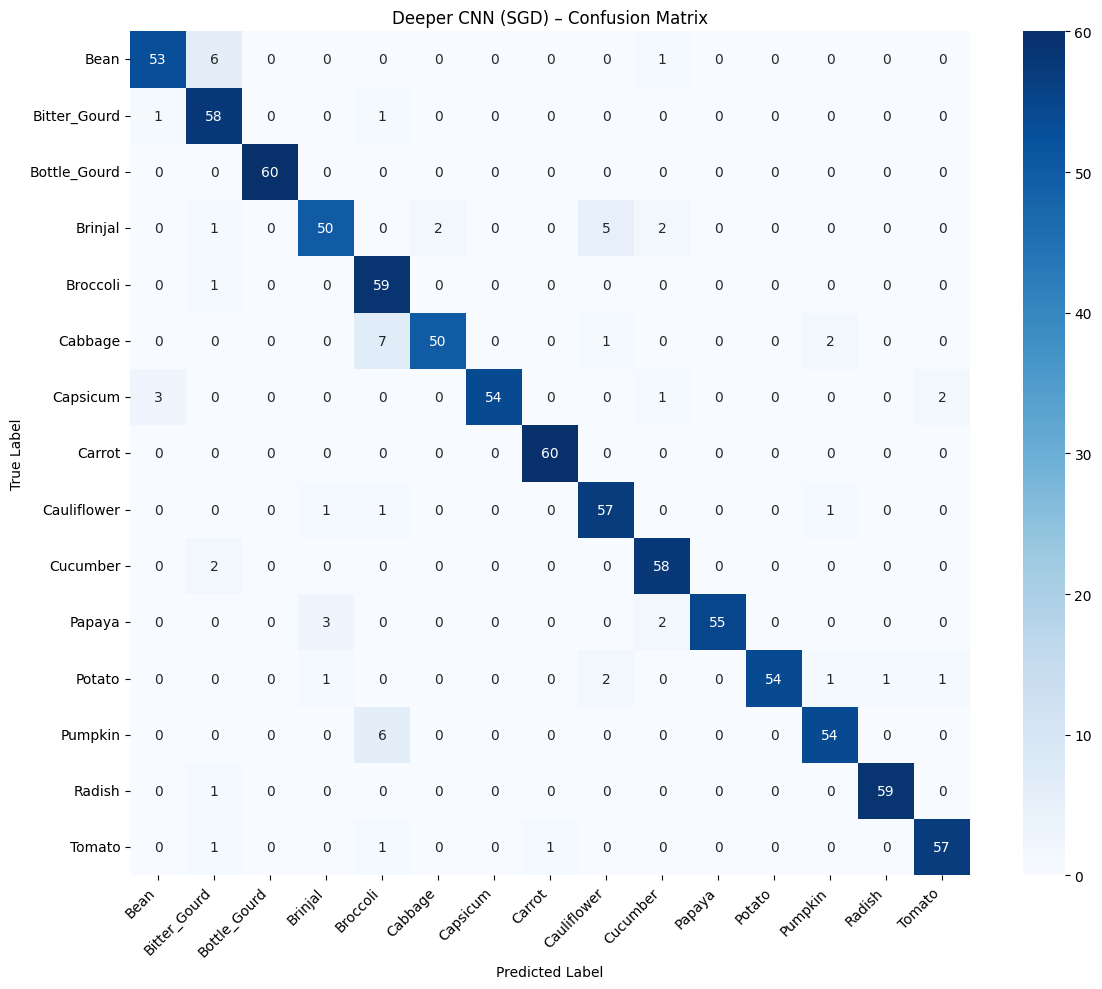

In [77]:
# Evaluate SGD model
sgd_loss, sgd_acc, _, _ = evaluate_model(deeper_sgd, test_gen, 'Deeper CNN (SGD)')

### Optimizer Analysis - SGD vs Adam


### D2. Ablation Study – Remove Dropout from Deeper Model

Training Ablation Model (No Dropout)...
Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 35s 184ms/step - accuracy: 0.4478 - loss: 1.7408 - val_accuracy: 0.0856 - val_loss: 4.5210 - learning_rate: 0.0010
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.7253 - loss: 0.8321 - val_accuracy: 0.1567 - val_loss: 3.8494 - learning_rate: 0.0010
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.8177 - loss: 0.5849 - val_accuracy: 0.4200 - val_loss: 2.2275 - learning_rate: 0.0010
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.8535 - loss: 0.4616 - val_accuracy: 0.6767 - val_loss: 1.5161 - learning_rate: 0.0010
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.8674 - loss: 0.4106 - val_accuracy: 0.7956 - val_loss: 0.6924 - learning_rate: 0.0010
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.9020 - loss: 0.3073 - val_accuracy: 0.8644 - val_loss: 0.4310 - learning_rate: 0.0010
Epoch 7/50
141/141 ━━━━━━━━━━━

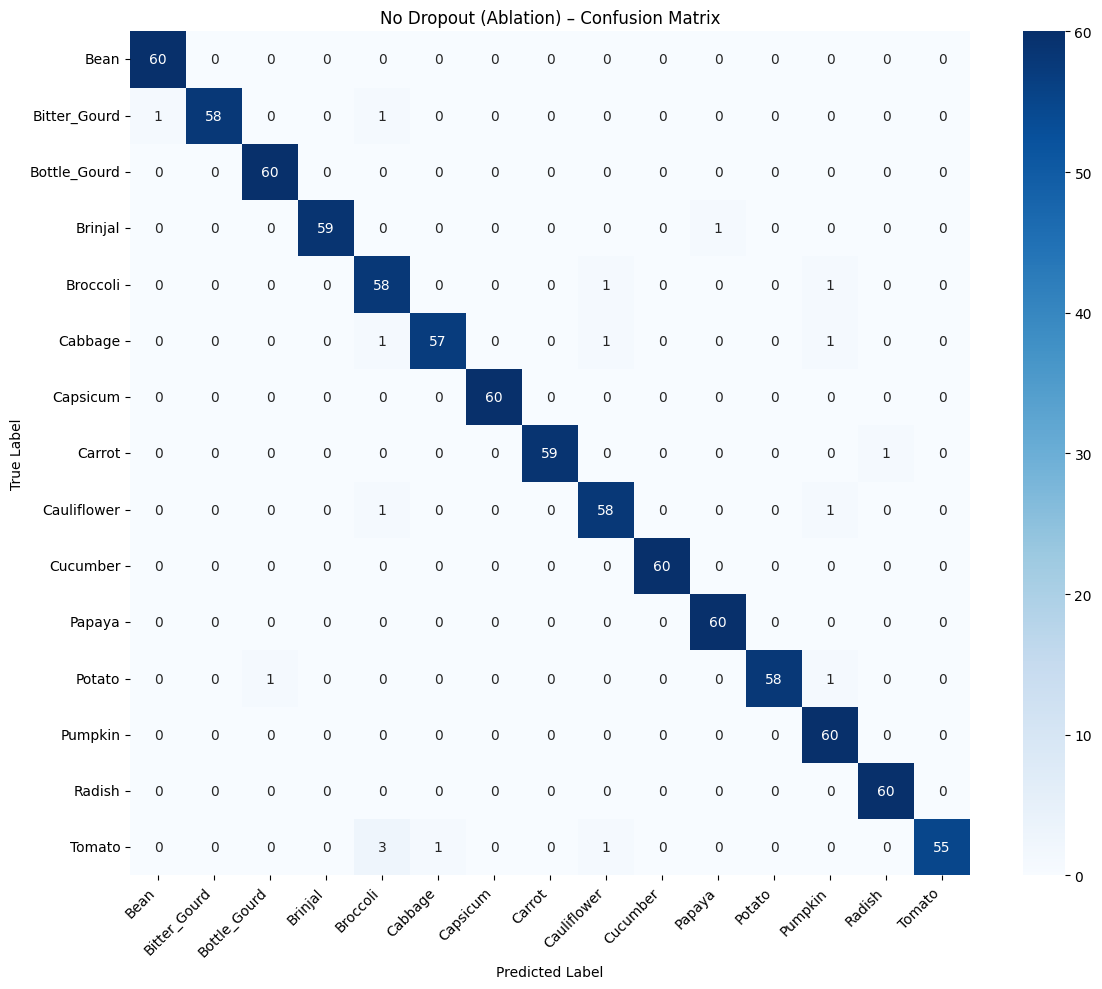

Ablation training time: 698.2s


In [78]:
def build_no_dropout_model(num_classes, input_shape=(128, 128, 3)):
    """Deeper model WITHOUT dropout layers – ablation study."""
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='No_Dropout_CNN')
    return model

ablation_model = build_no_dropout_model(NUM_CLASSES)
ablation_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Training Ablation Model (No Dropout)...")
t0 = time.time()
history_ablation = ablation_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=get_callbacks(), verbose=1
)
ablation_time = time.time() - t0
abl_loss, abl_acc, _, _ = evaluate_model(ablation_model, test_gen, 'No Dropout (Ablation)')
print(f"Ablation training time: {ablation_time:.1f}s")


### Ablation Study - Removing Dropout from the Deeper Model


### D3. Full Comparative Summary Table

In [79]:
print("\n" + "="*65)
print(f"{'Model':<30} {'Test Acc (%)':>12} {'Test Loss':>10} {'Train Time (s)':>15}")
print("="*65)
print(f"{'Baseline CNN (Adam)':<30} {bl_acc*100:>12.2f} {bl_loss:>10.4f} {baseline_train_time:>15.1f}")
print(f"{'Deeper CNN (Adam)':<30} {dp_acc*100:>12.2f} {dp_loss:>10.4f} {deeper_train_time:>15.1f}")
print(f"{'Deeper CNN (SGD)':<30} {sgd_acc*100:>12.2f} {sgd_loss:>10.4f} {sgd_time:>15.1f}")
print(f"{'No Dropout (Ablation)':<30} {abl_acc*100:>12.2f} {abl_loss:>10.4f} {ablation_time:>15.1f}")
print("="*65)


Model                          Test Acc (%)  Test Loss  Train Time (s)
Baseline CNN (Adam)                   97.33     0.1125           710.7
Deeper CNN (Adam)                     95.67     0.1692           479.8
Deeper CNN (SGD)                      93.11     0.2351           767.1
No Dropout (Ablation)                 98.00     0.0795           698.2


### Part A - Final Comparative Analysis and Conclusions


---
# PART B – Fine-Tuning a Pre-Trained Model (Transfer Learning)
---
## 2.6 - MobileNetV2 Transfer Learning

### E1. New Data Generators (224×224 for MobileNetV2)

In [80]:
IMG_SIZE_TL = (224, 224)

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2
)

tl_val_test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE, class_mode='categorical')

tl_val_gen = tl_val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

tl_test_gen = tl_val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

print("Transfer learning generators ready.")

Found 4500 images belonging to 15 classes.
Found 900 images belonging to 15 classes.
Found 900 images belonging to 15 classes.
Transfer learning generators ready.


### E2. Load MobileNetV2 – Feature Extraction Phase (Frozen Base)

In [ ]:
# Load pre-trained base 
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze ALL base layers for feature extraction phase
base_model.trainable = False

# Build custom head
inputs  = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='MobileNetV2_TL')

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Total params    : {tl_model.count_params():,}")
print(f"Trainable params: {sum([tf.size(v).numpy() for v in tl_model.trainable_variables]):,}")
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total params    : 2,625,871
Trainable params: 365,327


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625,871 (10.02 MB)

 Trainable params: 365,327 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

### E3. Phase 1 – Train Custom Head (Feature Extraction)

In [90]:
print("Phase 1: Feature Extraction (base frozen)...")
t0 = time.time()
history_tl_phase1 = tl_model.fit(
    tl_train_gen,
    epochs=50,
    validation_data=tl_val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
    ],
    verbose=1
)
phase1_time = time.time() - t0
print(f"Phase 1 training time: {phase1_time:.1f}s")

Phase 1: Feature Extraction (base frozen)...
Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 47s 334ms/step - accuracy: 0.9871 - loss: 0.0439 - val_accuracy: 0.9978 - val_loss: 0.0056 - learning_rate: 3.0000e-06
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 47s 332ms/step - accuracy: 0.9858 - loss: 0.0473 - val_accuracy: 0.9978 - val_loss: 0.0051 - learning_rate: 3.0000e-06
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 47s 334ms/step - accuracy: 0.9869 - loss: 0.0435 - val_accuracy: 0.9978 - val_loss: 0.0051 - learning_rate: 3.0000e-06
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 47s 332ms/step - accuracy: 0.9840 - loss: 0.0627 - val_accuracy: 0.9978 - val_loss: 0.0048 - learning_rate: 3.0000e-06
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 48s 337ms/step - accuracy: 0.9869 - loss: 0.0415 - val_accuracy: 0.9978 - val_loss: 0.0049 - learning_rate: 3.0000e-06
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 47s 333ms/step - accuracy: 0.9845 - loss: 0.0579 - val_accuracy: 0.9978 - val_loss: 0.0051 - learning_rate: 3.0000e-06
E

### E4. Phase 2 – Fine-Tuning (Unfreeze Top Layers)

In [91]:
# Unfreeze the top 50 layers of MobileNetV2 for fine-tuning
base_model.trainable = True
freeze_until = len(base_model.layers) - 50
for layer in base_model.layers[:freeze_until]:
    layer.trainable = False
trainable_count = sum([tf.size(v).numpy() for v in tl_model.trainable_variables])
print(f"Fine-tuning: {trainable_count:,} trainable params after unfreezing top 50 layers")
# Re-compile with LOWER learning rate to avoid catastrophic forgetting
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("\nPhase 2: Fine-Tuning (top 50 layers unfrozen)...")
t0 = time.time()
history_tl_phase2 = tl_model.fit(
    tl_train_gen,
    epochs=50,
    validation_data=tl_val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8)
    ],
    verbose=1
)
phase2_time = time.time() - t0
tl_total_time = phase1_time + phase2_time
print(f"Phase 2 training time: {phase2_time:.1f}s")
print(f"Total TL time:         {tl_total_time:.1f}s")

Fine-tuning: 2,220,431 trainable params after unfreezing top 50 layers

Phase 2: Fine-Tuning (top 50 layers unfrozen)...
Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 83s 451ms/step - accuracy: 0.9823 - loss: 0.0519 - val_accuracy: 0.9978 - val_loss: 0.0043 - learning_rate: 1.0000e-05
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 47s 331ms/step - accuracy: 0.9865 - loss: 0.0378 - val_accuracy: 0.9978 - val_loss: 0.0036 - learning_rate: 1.0000e-05
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 47s 330ms/step - accuracy: 0.9877 - loss: 0.0431 - val_accuracy: 0.9989 - val_loss: 0.0027 - learning_rate: 1.0000e-05
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 46s 329ms/step - accuracy: 0.9901 - loss: 0.0372 - val_accuracy: 0.9978 - val_loss: 0.0030 - learning_rate: 1.0000e-05
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 47s 332ms/step - accuracy: 0.9902 - loss: 0.0300 - val_accuracy: 0.9989 - val_loss: 0.0037 - learning_rate: 1.0000e-05
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 48s 342ms/step - accuracy: 0.9874 - loss: 0.

### E5. Plot Transfer Learning History (Both Phases Combined)

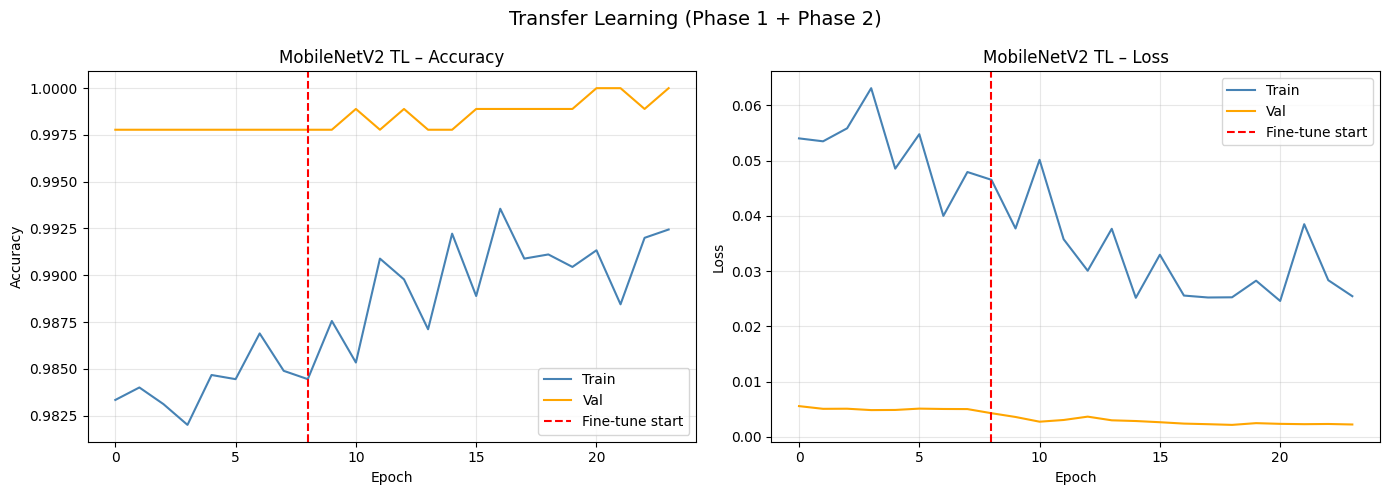

In [92]:
# Combine both phases
acc_combined     = (history_tl_phase1.history['accuracy'] +
                    history_tl_phase2.history['accuracy'])
val_acc_combined = (history_tl_phase1.history['val_accuracy'] +
                    history_tl_phase2.history['val_accuracy'])
loss_combined    = (history_tl_phase1.history['loss'] +
                    history_tl_phase2.history['loss'])
val_loss_combined= (history_tl_phase1.history['val_loss'] +
                    history_tl_phase2.history['val_loss'])

phase_boundary = len(history_tl_phase1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(acc_combined,     label='Train', color='steelblue')
axes[0].plot(val_acc_combined, label='Val',   color='orange')
axes[0].axvline(phase_boundary, color='red', linestyle='--', label='Fine-tune start')
axes[0].set_title('MobileNetV2 TL – Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_combined,     label='Train', color='steelblue')
axes[1].plot(val_loss_combined, label='Val',   color='orange')
axes[1].axvline(phase_boundary, color='red', linestyle='--', label='Fine-tune start')
axes[1].set_title('MobileNetV2 TL – Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Transfer Learning (Phase 1 + Phase 2)', fontsize=14)
plt.tight_layout()
plt.show()

### E6. Evaluate Transfer Learning Model


MobileNetV2 TL – Test Results
  Test Loss    : 0.0363
  Test Accuracy: 99.56%

Classification Report:
              precision    recall  f1-score   support

        Bean      1.000     1.000     1.000        60
Bitter_Gourd      1.000     0.983     0.992        60
Bottle_Gourd      1.000     1.000     1.000        60
     Brinjal      0.984     1.000     0.992        60
    Broccoli      0.984     1.000     0.992        60
     Cabbage      1.000     0.983     0.992        60
    Capsicum      1.000     1.000     1.000        60
      Carrot      1.000     1.000     1.000        60
 Cauliflower      0.968     1.000     0.984        60
    Cucumber      1.000     0.983     0.992        60
      Papaya      1.000     1.000     1.000        60
      Potato      1.000     1.000     1.000        60
     Pumpkin      1.000     0.983     0.992        60
      Radish      1.000     1.000     1.000        60
      Tomato      1.000     1.000     1.000        60

    accuracy                   

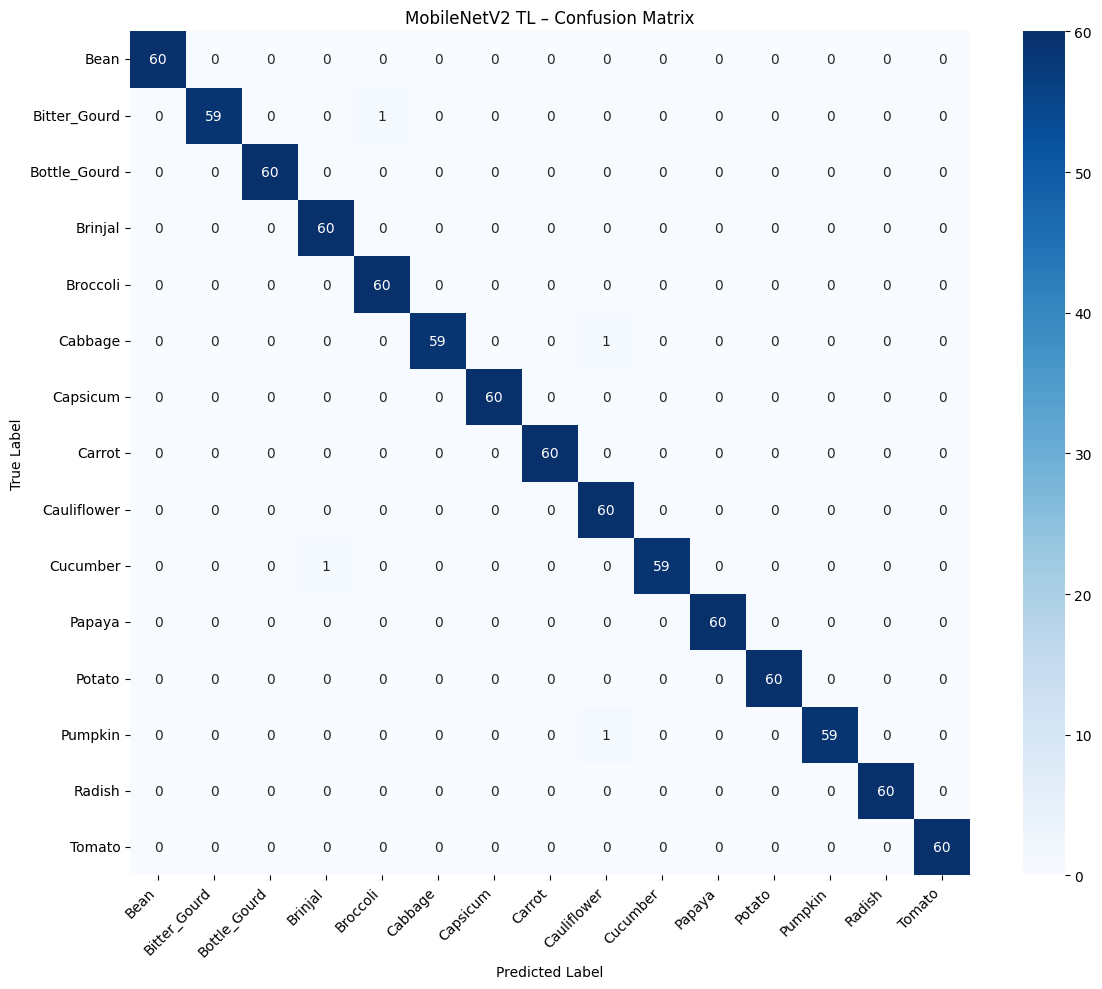

In [93]:
tl_loss, tl_acc, tl_pred, tl_true = evaluate_model(tl_model, tl_test_gen, 'MobileNetV2 TL')

### 2.6 — Transfer Learning: Evaluation and Discussion

### E7. Sample Predictions - Transfer Learning Model

Found 900 images belonging to 15 classes.


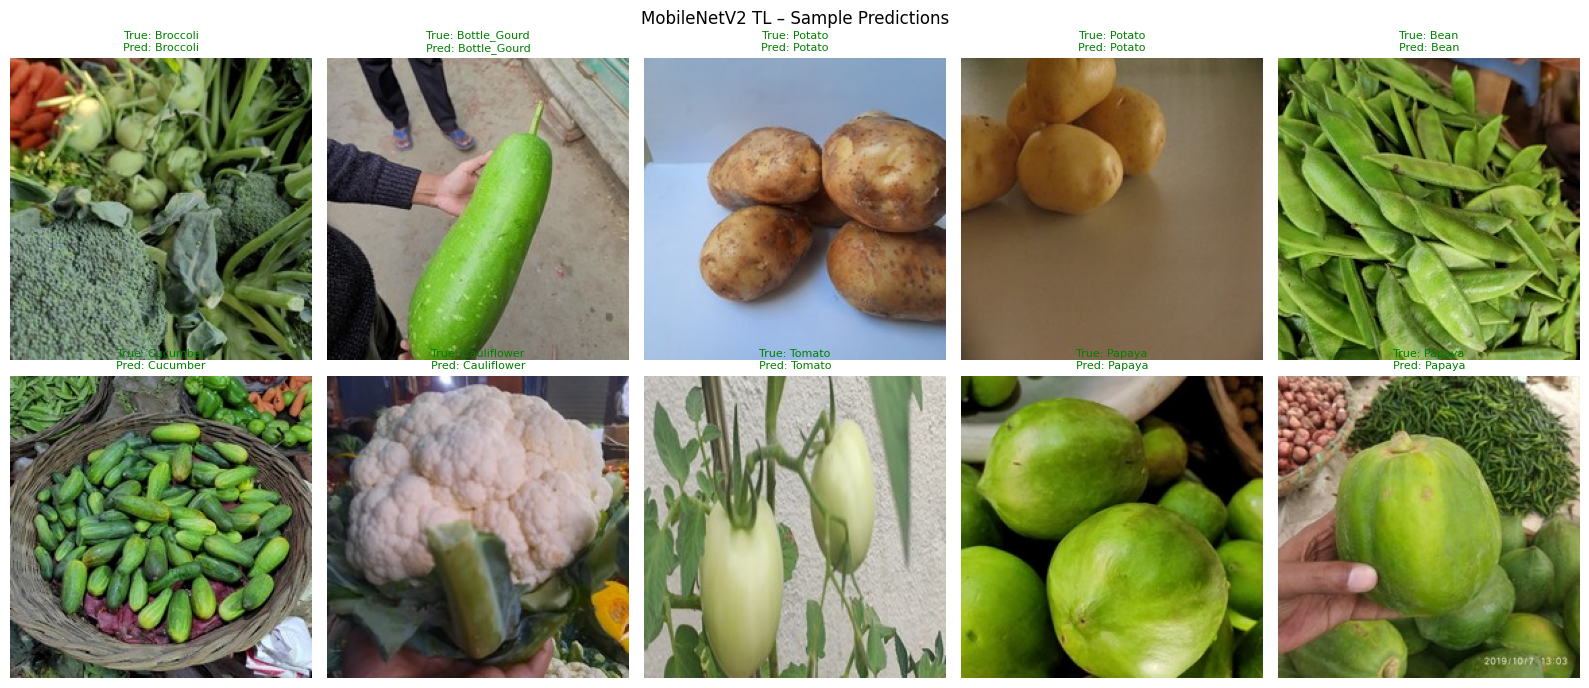

In [ ]:
def show_tl_predictions(model, test_dir, class_names, n=10, img_size=(224,224), title='TL Model'):
    datagen = ImageDataGenerator(
        preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)
    gen = datagen.flow_from_directory(test_dir, target_size=img_size,
                                       batch_size=n, class_mode='categorical', shuffle=True)
    imgs, labels = next(gen)

    # Undo preprocess for display
    display_imgs = (imgs + 1) / 2.0  
    preds = np.argmax(model.predict(imgs, verbose=0), axis=1)
    trues = np.argmax(labels, axis=1)

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    axes = axes.flatten()
    for i in range(n):
        axes[i].imshow(np.clip(display_imgs[i], 0, 1))
        color = 'green' if preds[i] == trues[i] else 'red'
        axes[i].set_title(
            f"True: {class_names[trues[i]]}\nPred: {class_names[preds[i]]}",
            color=color, fontsize=8)
        axes[i].axis('off')
    fig.suptitle(f'{title} – Sample Predictions', fontsize=12)
    plt.tight_layout()
    plt.show()

show_tl_predictions(tl_model, TEST_DIR, class_names_list, n=10, title='MobileNetV2 TL')

---
## Final Summary - All Models Compared


Model                               Test Acc (%)  Test Loss  Train Time (s)
Baseline CNN (Adam)                        97.33     0.1125           710.7
Deeper CNN (Adam)                          95.67     0.1692           479.8
Deeper CNN (SGD)                           93.11     0.2351           767.1
No Dropout (Ablation)                      98.00     0.0795           698.2
MobileNetV2 (Transfer Learning)            99.56     0.0363          1166.9


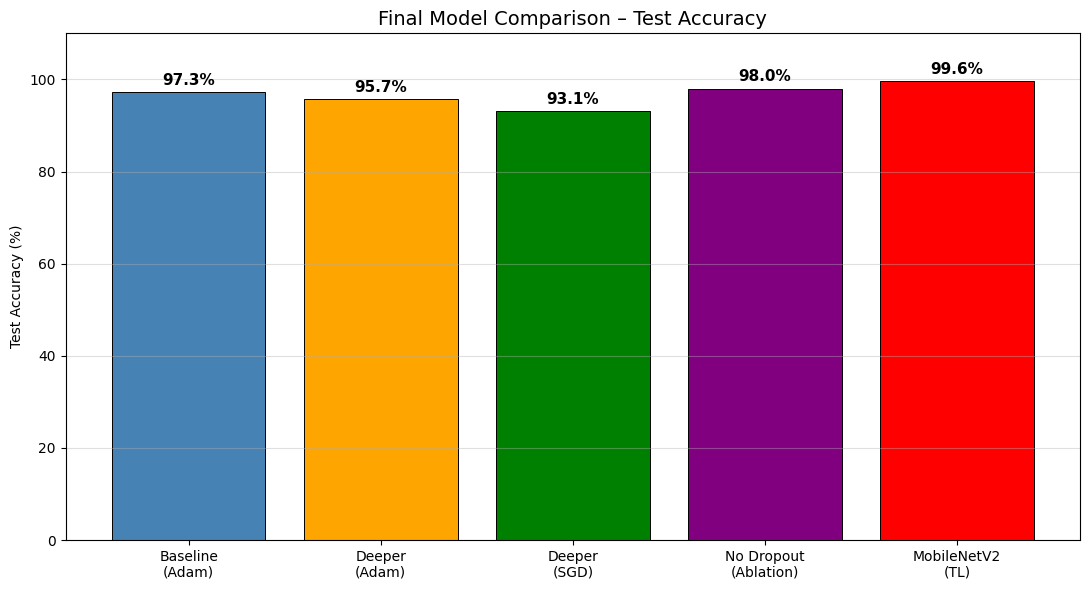

In [ ]:
# Summary Table 
print("\n" + "="*75)
print(f"{'Model':<35} {'Test Acc (%)':>12} {'Test Loss':>10} {'Train Time (s)':>15}")
print("="*75)
print(f"{'Baseline CNN (Adam)':<35} {bl_acc*100:>12.2f} {bl_loss:>10.4f} {baseline_train_time:>15.1f}")
print(f"{'Deeper CNN (Adam)':<35} {dp_acc*100:>12.2f} {dp_loss:>10.4f} {deeper_train_time:>15.1f}")
print(f"{'Deeper CNN (SGD)':<35} {sgd_acc*100:>12.2f} {sgd_loss:>10.4f} {sgd_time:>15.1f}")
print(f"{'No Dropout (Ablation)':<35} {abl_acc*100:>12.2f} {abl_loss:>10.4f} {ablation_time:>15.1f}")
print(f"{'MobileNetV2 (Transfer Learning)':<35} {tl_acc*100:>12.2f} {tl_loss:>10.4f} {tl_total_time:>15.1f}")
print("="*75)

# Bar Chart Comparison
model_names = ['Baseline\n(Adam)', 'Deeper\n(Adam)', 'Deeper\n(SGD)', 'No Dropout\n(Ablation)', 'MobileNetV2\n(TL)']
accs = [bl_acc*100, dp_acc*100, sgd_acc*100, abl_acc*100, tl_acc*100]
colors_bar = ['steelblue', 'orange', 'green', 'purple', 'red']

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(model_names, accs, color=colors_bar, edgecolor='black', linewidth=0.7)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11, fontweight='bold')
ax.set_title('Final Model Comparison – Test Accuracy', fontsize=14)
ax.set_ylabel('Test Accuracy (%)')
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

### Final Summary - All Models Compared


### Save All Models

In [96]:
# Models saved to /kaggle/working/ — downloadable from Output tab
baseline_model.save('/kaggle/working/model_baseline.h5')
deeper_model.save('/kaggle/working/model_deeper.h5')
tl_model.save('/kaggle/working/model_tl_mobilenetv2.h5')
print('All models saved to /kaggle/working/')


All models saved to /kaggle/working/
